# Notebook 4 — Exploratory Data Analysis (Final 19 Features)

This notebook performs a comprehensive exploratory data analysis on the finalised traffic feature dataset (`traffic_features_final`), which was produced at the end of Notebook 3 — Feature Analysis, Importance & Selection.

The dataset contains **19 input features** and the target variable `vehicle_count`, representing cleaned and engineered hourly traffic records from Irish road sensors throughout 2019.

The EDA is structured into five sections:

1. **Dataset Overview** — schema, shape, feature categories, and descriptive statistics
2. **Target Variable Analysis** — distribution, skewness, and temporal patterns of `vehicle_count`
3. **Feature Distributions & Outlier Inspection** — per-feature distribution plots and boxplots
4. **Feature vs Target Analysis** — how each feature relates to the target, including scatter plots, group means, and correlation strengths
5. **Feature vs Feature Analysis** — correlation heatmap and pairwise relationships among input features

## 1. Dataset Overview

We begin by loading the final feature dataset and inspecting its structure — schema, row count, column count, and feature categories.

### 1.1 Load Dataset

In [0]:
# Load the final feature dataset
df = spark.table("traffic_features_final")

print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")
print()
df.printSchema()

Rows    : 7,503,913
Columns : 20

root
 |-- avg_speed: double (nullable = true)
 |-- max_speed: double (nullable = true)
 |-- min_speed: double (nullable = true)
 |-- speed_std: double (nullable = true)
 |-- avg_length: double (nullable = true)
 |-- max_length: double (nullable = true)
 |-- length_std: double (nullable = true)
 |-- avg_headway: double (nullable = true)
 |-- min_headway: double (nullable = true)
 |-- avg_gap: double (nullable = true)
 |-- min_gap: double (nullable = true)
 |-- month: long (nullable = true)
 |-- day: long (nullable = true)
 |-- hour: long (nullable = true)
 |-- cosit: long (nullable = true)
 |-- lane: long (nullable = true)
 |-- day_type_index: double (nullable = true)
 |-- speed_category_index: double (nullable = true)
 |-- congestion_index_index: double (nullable = true)
 |-- vehicle_count: long (nullable = true)



### 1.2 Feature Categories

The 19 features are grouped into four categories for structured analysis throughout this notebook.

In [0]:
# Define the final 19 features and target
sensor_features = [
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "min_headway",
    "avg_gap", "min_gap"
]

temporal_features = ["month", "day", "hour"]

location_features = ["cosit", "lane"]

encoded_features = [
    "day_type_index", "speed_category_index", "congestion_index_index"
]

all_features = sensor_features + temporal_features + location_features + encoded_features
target = "vehicle_count"

categories = {
    "Sensor Measurements" : sensor_features,
    "Temporal"            : temporal_features,
    "Location Identifiers": location_features,
    "Encoded Categorical" : encoded_features,
}

print(f"{'Category':<25} {'Count':>5}   Columns")
print("-" * 90)
for cat, cols in categories.items():
    print(f"{cat:<25} {len(cols):>5}   {cols}")
print("-" * 90)
print(f"{'Total Features':<25} {len(all_features):>5}")
print(f"{'Target':<25}         {target}")

Category                  Count   Columns
------------------------------------------------------------------------------------------
Sensor Measurements          11   ['avg_speed', 'max_speed', 'min_speed', 'speed_std', 'avg_length', 'max_length', 'length_std', 'avg_headway', 'min_headway', 'avg_gap', 'min_gap']
Temporal                      3   ['month', 'day', 'hour']
Location Identifiers          2   ['cosit', 'lane']
Encoded Categorical           3   ['day_type_index', 'speed_category_index', 'congestion_index_index']
------------------------------------------------------------------------------------------
Total Features               19
Target                            vehicle_count


### 1.3 Descriptive Statistics

Summary statistics (count, mean, standard deviation, min, max) are computed for all 19 features and the target variable. This gives an immediate sense of the scale, spread, and range of each column.

In [0]:
# Full descriptive statistics for all features + target
display(df.select(all_features + [target]).describe())

summary,avg_speed,max_speed,min_speed,speed_std,avg_length,max_length,length_std,avg_headway,min_headway,avg_gap,min_gap,month,day,hour,cosit,lane,day_type_index,speed_category_index,congestion_index_index,vehicle_count
count,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913,7503913
mean,94.46244486460053,131.26633692315136,59.17935783637315,12.07454366767734,5.314659992341394,15.374347986176932,2.262291848425871,31.75830092486315,0.006135597520920077,31.720196222835106,0.009168056719207781,6.0936147580602285,15.504413897122742,11.62254906206935,24792.5085085608,2.507465771524803,0.28890553501886285,1.4994973955588238,1.4993184222684885,295.3811885878741
stddev,19.67691660657992,26.115206992390146,27.239216442507942,3.9378018562024226,1.3871551295313105,5.523886025818202,1.5892048734799225,45.05093394144268,0.07118661346361496,45.438824101034484,0.40663525806856,3.2641279031405426,8.755260569571908,6.88792210158062,52043.518229691465,1.5875849202599506,0.4532539621800684,1.118138896363367,1.1179517868617357,350.87541378762927
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,997,1,0.0,0.0,0.0,1
max,224.5,235.0,218.0,50.91449414740084,18.95,64.3,15.839191898578667,801.0,10.37,833.1033333333334,94.77,12,31,23,208001,9,1.0,3.0,3.0,2594


In [0]:
# Quartile statistics (25%, 50%, 75%) — complements describe()
display(df.select(all_features + [target]).summary("25%", "50%", "75%"))

summary,avg_speed,max_speed,min_speed,speed_std,avg_length,max_length,length_std,avg_headway,min_headway,avg_gap,min_gap,month,day,hour,cosit,lane,day_type_index,speed_category_index,congestion_index_index,vehicle_count
25%,83.69444444444444,116.0,40.0,9.917168115650153,4.564705882352942,12.1,0.9534853347745074,7.276012024048097,0.0,7.031425619834715,0.0,3,8,6,1283,1,0.0,0.0,0.0,43
50%,94.42857142857143,132.0,62.0,11.665223314053058,4.894075403949731,17.6,1.9680342289843653,17.13314720812183,0.0,16.973789473684214,0.0,6,15,12,3804,2,0.0,1.0,1.0,161
75%,108.22522522522523,149.0,77.0,13.832119730246847,5.636842105263158,19.0,3.2819755691296115,42.99661538461539,0.0,43.02033898305084,0.0,9,23,18,20152,3,1.0,2.0,2.0,418


### 1.4 Missing Values Check

Although the dataset was cleaned in Notebook 2, we confirm there are no residual null values in the final feature set.

In [0]:
from pyspark.sql.functions import col, sum as spark_sum

total_rows = df.count()

print(f"{'Column':<30} {'Null Count':>12} {'Null %':>10} {'Status':>8}")
print("-" * 65)
for c in all_features + [target]:
    n = df.filter(col(c).isNull()).count()
    pct = (n / total_rows) * 100
    flag = "NULLS" if n > 0 else "CLEAN"
    print(f"{c:<30} {n:>12,} {pct:>9.2f}%   {flag}")

Column                           Null Count     Null %   Status
-----------------------------------------------------------------
avg_speed                                 0      0.00%   CLEAN
max_speed                                 0      0.00%   CLEAN
min_speed                                 0      0.00%   CLEAN
speed_std                                 0      0.00%   CLEAN
avg_length                                0      0.00%   CLEAN
max_length                                0      0.00%   CLEAN
length_std                                0      0.00%   CLEAN
avg_headway                               0      0.00%   CLEAN
min_headway                               0      0.00%   CLEAN
avg_gap                                   0      0.00%   CLEAN
min_gap                                   0      0.00%   CLEAN
month                                     0      0.00%   CLEAN
day                                       0      0.00%   CLEAN
hour                                      0      0.

---

## 2. Target Variable Analysis — `vehicle_count`

Before analysing any features, we thoroughly explore the target variable `vehicle_count`. Understanding its distribution, skewness, and temporal patterns is essential context for interpreting all subsequent feature relationships.

### 2.1 Distribution of `vehicle_count`

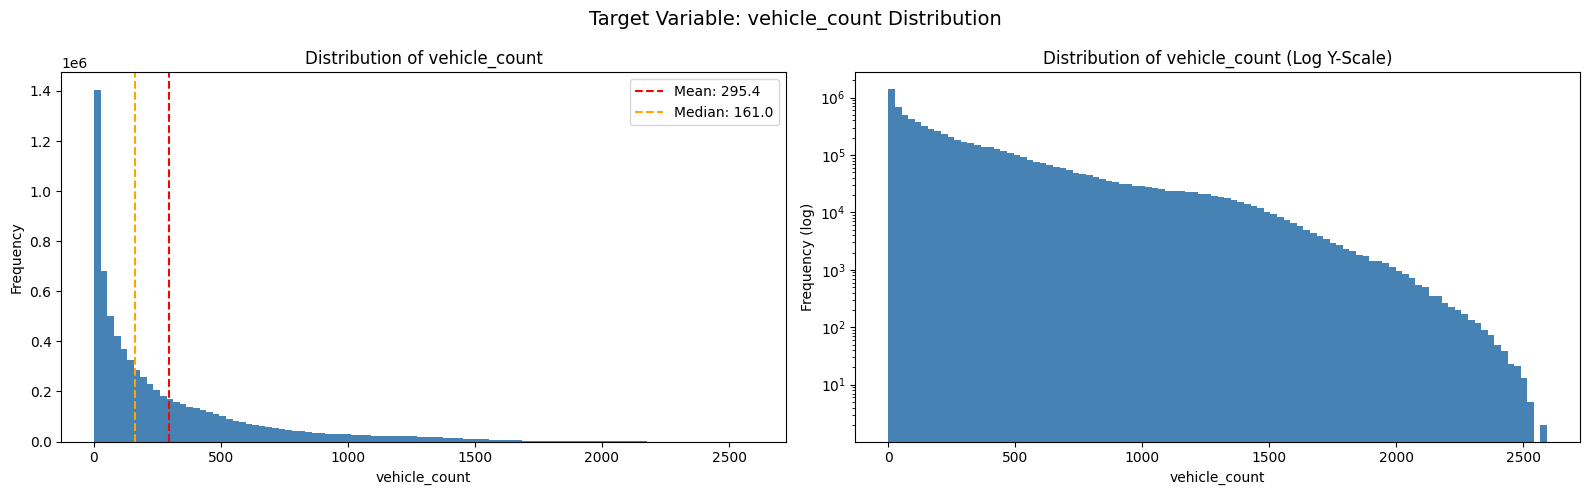

Mean     : 295.38
Median   : 161.00
Std Dev  : 350.88
Skewness : 1.8093
Kurtosis : 3.2979
Min      : 1
Max      : 2594


In [0]:
import matplotlib.pyplot as plt
import numpy as np

vc_pdf = df.select("vehicle_count").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(vc_pdf["vehicle_count"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Distribution of vehicle_count")
axes[0].set_xlabel("vehicle_count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(vc_pdf["vehicle_count"].mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean: {vc_pdf['vehicle_count'].mean():.1f}")
axes[0].axvline(vc_pdf["vehicle_count"].median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median: {vc_pdf['vehicle_count'].median():.1f}")
axes[0].legend()

# Log-scale histogram
axes[1].hist(vc_pdf["vehicle_count"], bins=100, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_title("Distribution of vehicle_count (Log Y-Scale)")
axes[1].set_xlabel("vehicle_count")
axes[1].set_ylabel("Frequency (log)")

plt.suptitle("Target Variable: vehicle_count Distribution", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Mean     : {vc_pdf['vehicle_count'].mean():.2f}")
print(f"Median   : {vc_pdf['vehicle_count'].median():.2f}")
print(f"Std Dev  : {vc_pdf['vehicle_count'].std():.2f}")
print(f"Skewness : {vc_pdf['vehicle_count'].skew():.4f}")
print(f"Kurtosis : {vc_pdf['vehicle_count'].kurt():.4f}")
print(f"Min      : {vc_pdf['vehicle_count'].min()}")
print(f"Max      : {vc_pdf['vehicle_count'].max()}")

### 2.2 Hourly Traffic Patterns

Mean `vehicle_count` is computed for each hour of the day to reveal the daily traffic rhythm — the characteristic peak and off-peak structure of Irish road traffic.

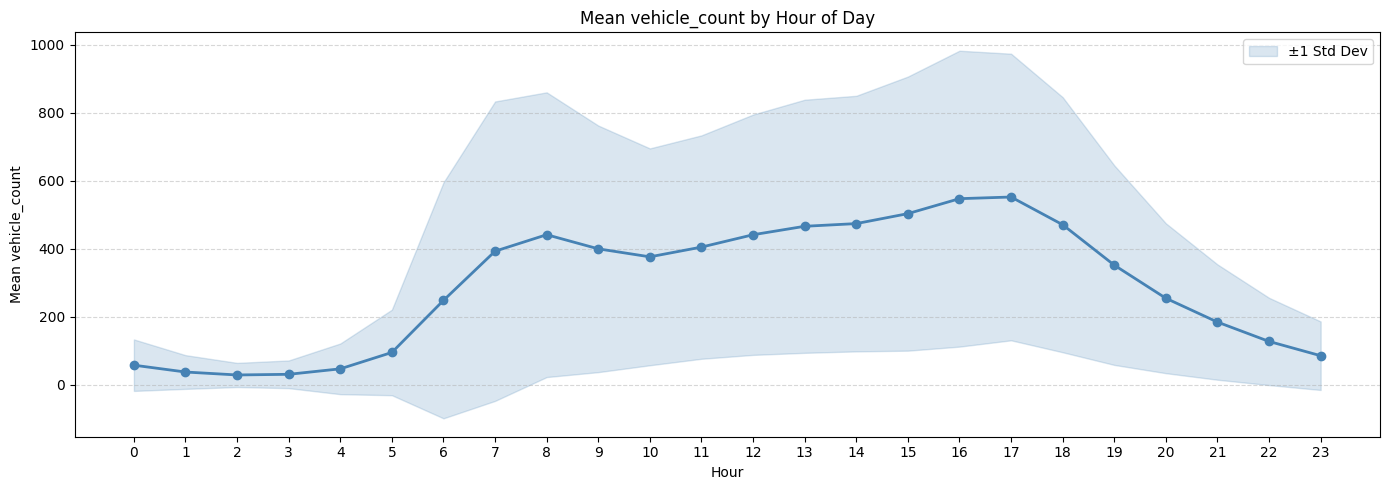

In [0]:
from pyspark.sql.functions import avg, stddev

hourly_pdf = df.groupBy("hour").agg(
    avg("vehicle_count").alias("mean_vc"),
    stddev("vehicle_count").alias("std_vc")
).orderBy("hour").toPandas()

plt.figure(figsize=(14, 5))
plt.plot(hourly_pdf["hour"], hourly_pdf["mean_vc"], marker="o", color="steelblue", linewidth=2)
plt.fill_between(
    hourly_pdf["hour"],
    hourly_pdf["mean_vc"] - hourly_pdf["std_vc"],
    hourly_pdf["mean_vc"] + hourly_pdf["std_vc"],
    alpha=0.2, color="steelblue", label="±1 Std Dev"
)
plt.xticks(range(0, 24))
plt.title("Mean vehicle_count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean vehicle_count")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 2.3 Monthly and Daily Traffic Patterns

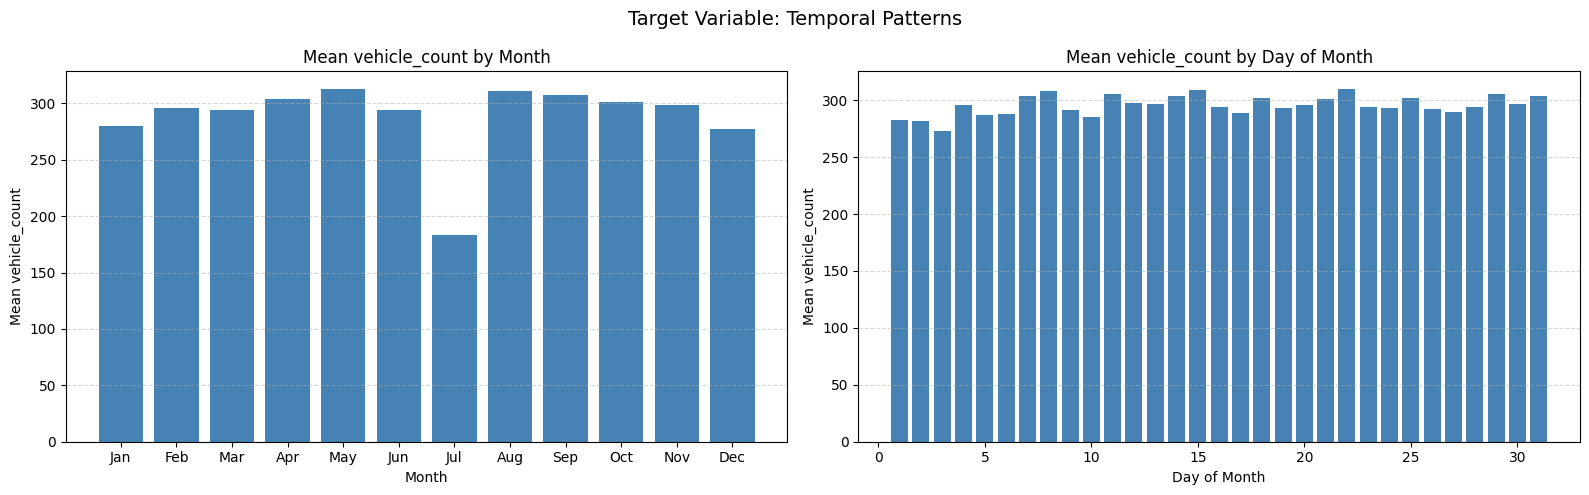

In [0]:
monthly_pdf = df.groupBy("month").agg(
    avg("vehicle_count").alias("mean_vc")
).orderBy("month").toPandas()

daily_pdf = df.groupBy("day").agg(
    avg("vehicle_count").alias("mean_vc")
).orderBy("day").toPandas()

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(monthly_pdf["month"], monthly_pdf["mean_vc"], color="steelblue", edgecolor="none")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_title("Mean vehicle_count by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean vehicle_count")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].bar(daily_pdf["day"], daily_pdf["mean_vc"], color="steelblue", edgecolor="none")
axes[1].set_title("Mean vehicle_count by Day of Month")
axes[1].set_xlabel("Day of Month")
axes[1].set_ylabel("Mean vehicle_count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Target Variable: Temporal Patterns", fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Traffic by Location — `cosit` and `lane`

Mean `vehicle_count` is aggregated by sensor site (`cosit`) and lane to understand how traffic volume varies across measurement locations.

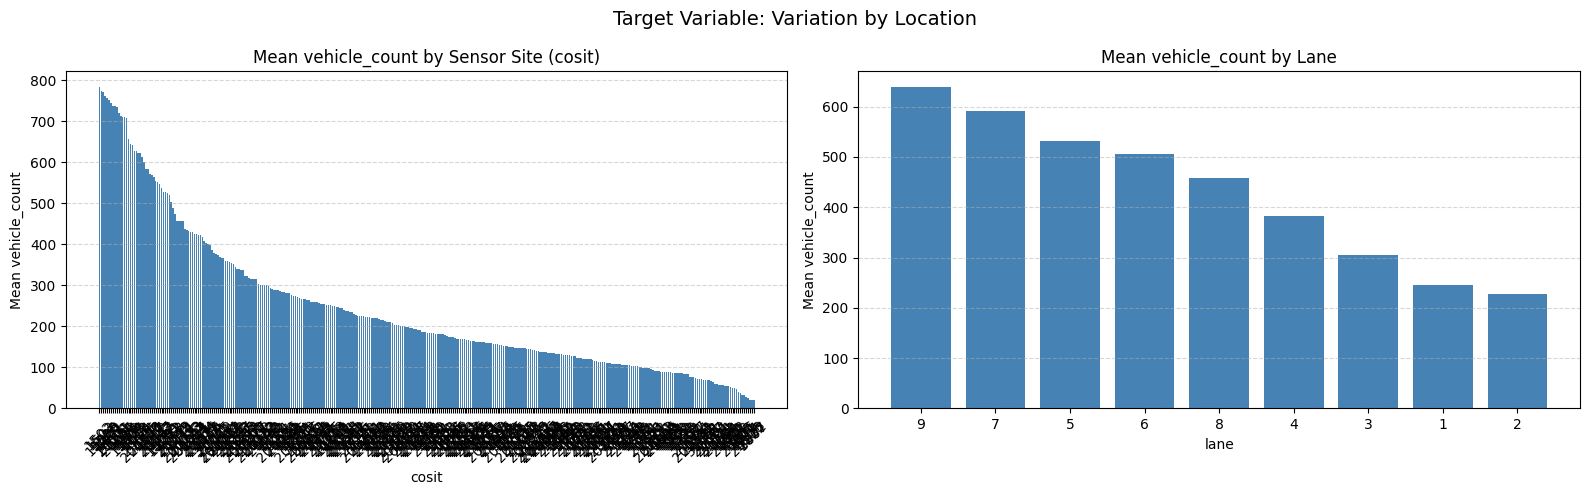

Unique cosit values : 338
Unique lane values  : 9


In [0]:
cosit_pdf = df.groupBy("cosit").agg(
    avg("vehicle_count").alias("mean_vc")
).orderBy("mean_vc", ascending=False).toPandas()

lane_pdf = df.groupBy("lane").agg(
    avg("vehicle_count").alias("mean_vc")
).orderBy("mean_vc", ascending=False).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(cosit_pdf["cosit"].astype(str), cosit_pdf["mean_vc"], color="steelblue", edgecolor="none")
axes[0].set_title("Mean vehicle_count by Sensor Site (cosit)")
axes[0].set_xlabel("cosit")
axes[0].set_ylabel("Mean vehicle_count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].bar(lane_pdf["lane"].astype(str), lane_pdf["mean_vc"], color="steelblue", edgecolor="none")
axes[1].set_title("Mean vehicle_count by Lane")
axes[1].set_xlabel("lane")
axes[1].set_ylabel("Mean vehicle_count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Target Variable: Variation by Location", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Unique cosit values : {df.select('cosit').distinct().count()}")
print(f"Unique lane values  : {df.select('lane').distinct().count()}")

---

## 3. Feature Distributions & Outlier Inspection

We examine the distribution of each individual feature. For sensor measurement features, histograms and boxplots are shown together — histograms reveal the shape of the distribution while boxplots highlight the spread and any remaining extreme values. Temporal and encoded categorical features are shown as bar charts of value frequencies.

### 3.1 Sensor Measurement Features — Histograms

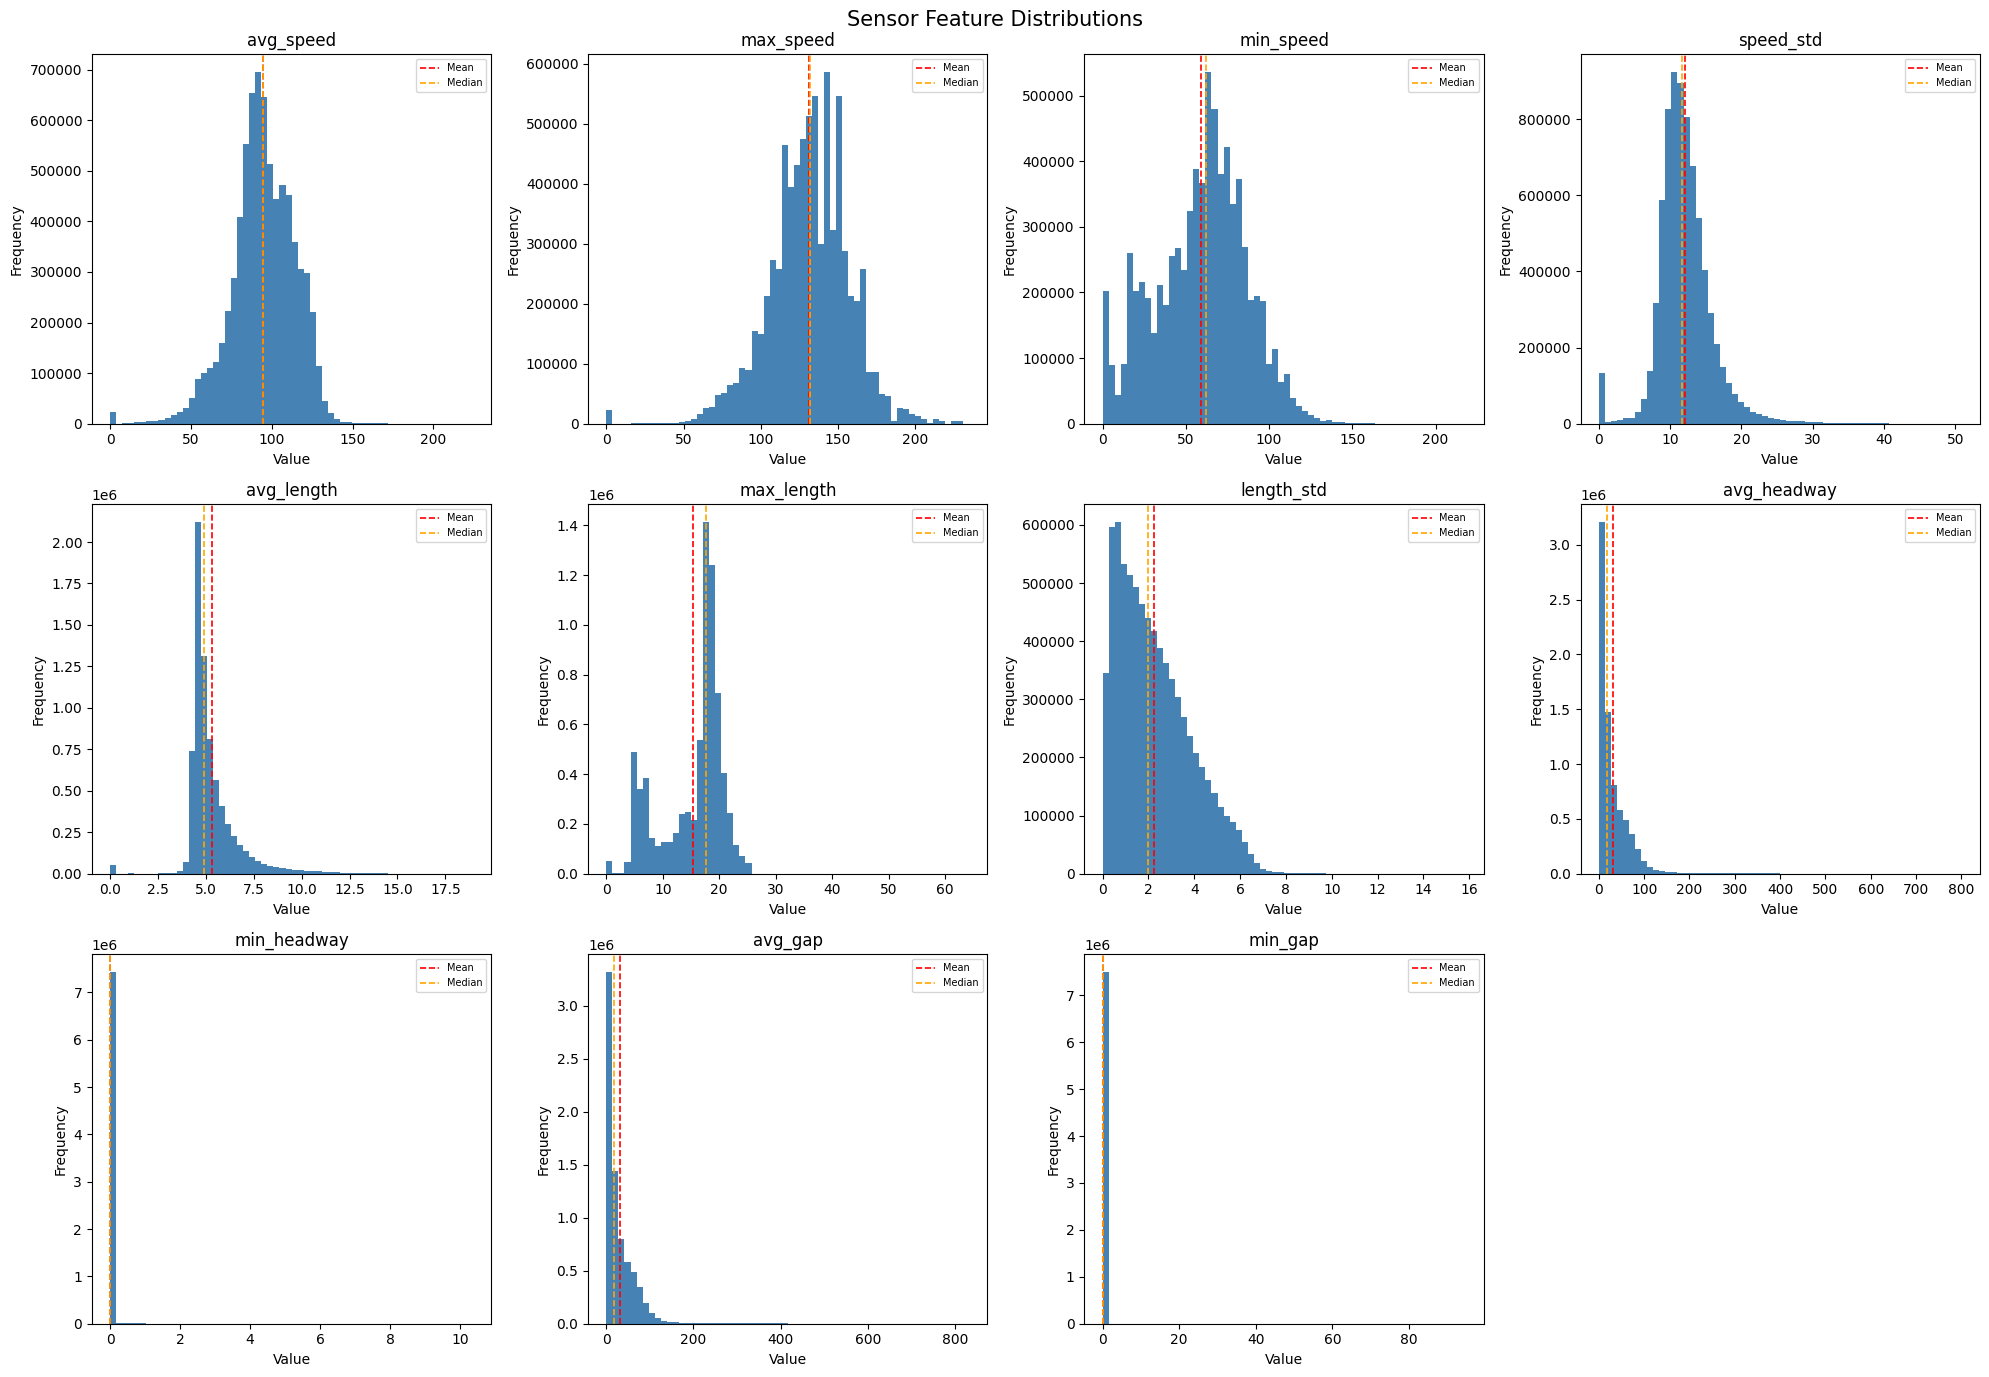

In [0]:
sensor_pdf = df.select(sensor_features).toPandas()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    axes[i].hist(sensor_pdf[feat].dropna(), bins=60, color="steelblue", edgecolor="none")
    axes[i].set_title(feat)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(sensor_pdf[feat].mean(),   color="red",    linestyle="--", linewidth=1.2, label="Mean")
    axes[i].axvline(sensor_pdf[feat].median(), color="orange", linestyle="--", linewidth=1.2, label="Median")
    axes[i].legend(fontsize=7)

for j in range(len(sensor_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sensor Feature Distributions", fontsize=15)
plt.tight_layout()
plt.show()

### 3.2 Sensor Measurement Features — Boxplots

Boxplots reveal the interquartile range, median, and any extreme values remaining after the outlier removal step in Notebook 2.

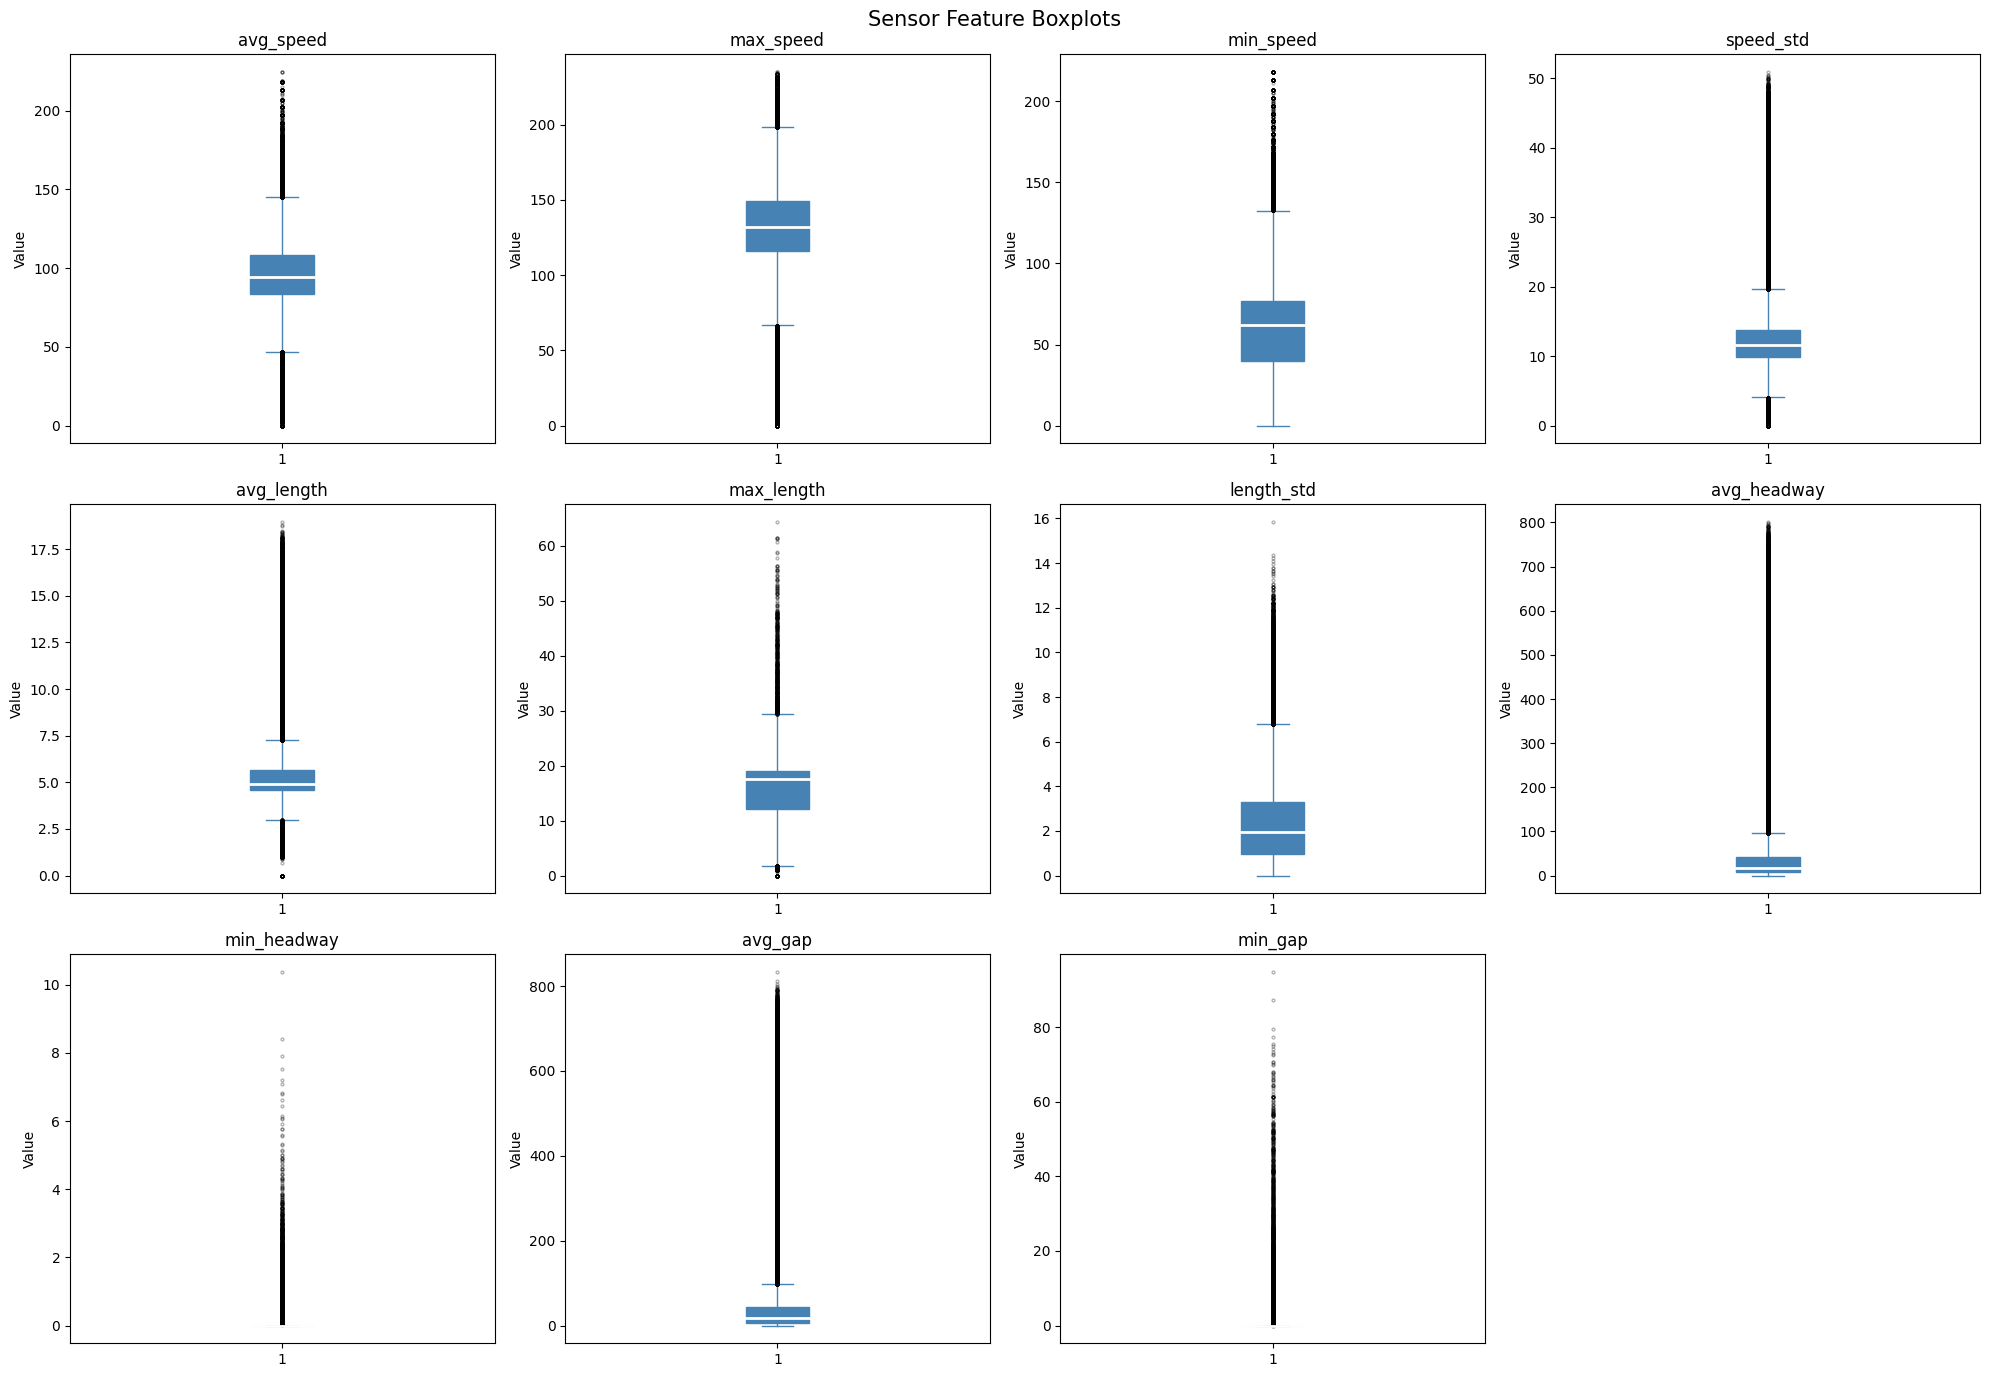

In [0]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    axes[i].boxplot(sensor_pdf[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", color="steelblue"),
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="steelblue"),
                    capprops=dict(color="steelblue"),
                    flierprops=dict(marker="o", color="tomato", alpha=0.3, markersize=2))
    axes[i].set_title(feat)
    axes[i].set_ylabel("Value")

for j in range(len(sensor_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sensor Feature Boxplots", fontsize=15)
plt.tight_layout()
plt.show()

### 3.3 Temporal Feature Distributions

Bar charts show the count of records per value for `month`, `day`, and `hour`. A well-distributed dataset should show relatively uniform counts — significant imbalances would indicate data gaps or seasonal collection issues.

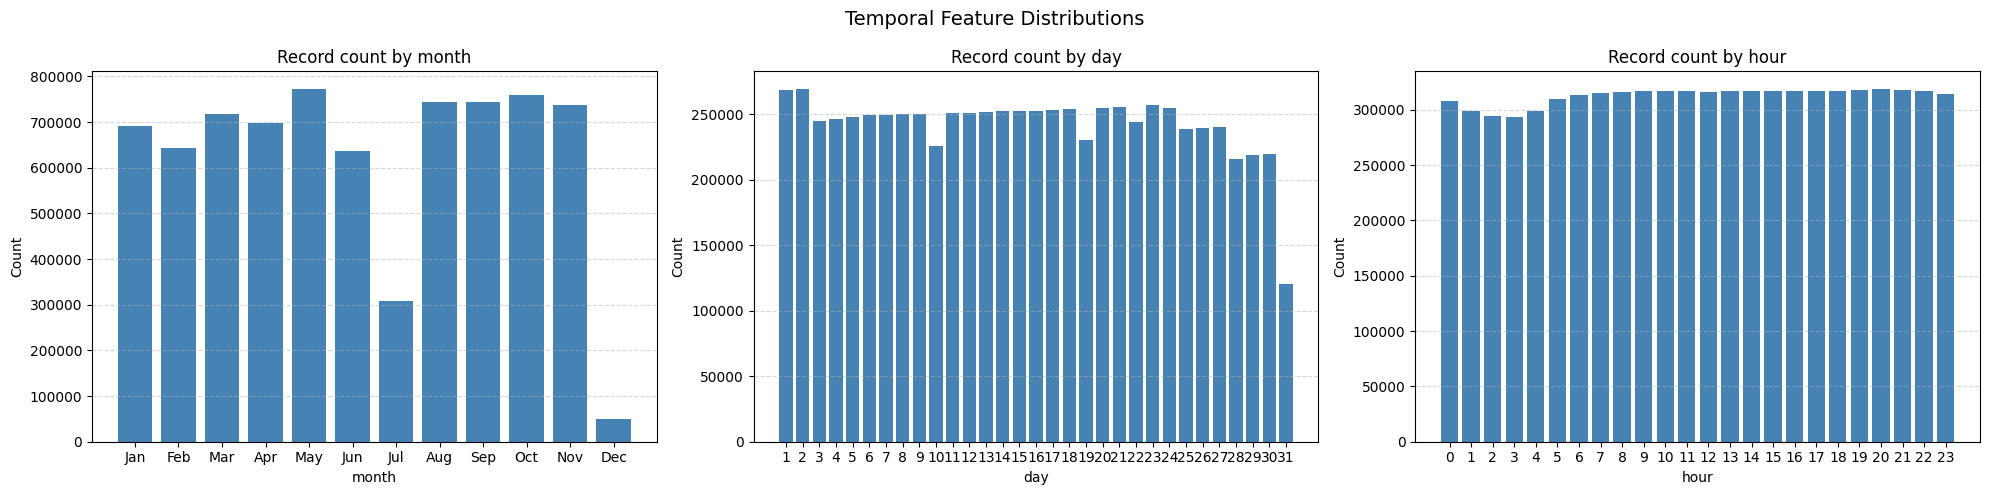

In [0]:
from pyspark.sql.functions import count

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, feat in enumerate(temporal_features):
    t_pdf = df.groupBy(feat).agg(count("*").alias("cnt")).orderBy(feat).toPandas()
    axes[i].bar(t_pdf[feat].astype(str), t_pdf["cnt"], color="steelblue", edgecolor="none")
    axes[i].set_title(f"Record count by {feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)
    if feat == "month":
        axes[i].set_xticks(range(len(month_labels)))
        axes[i].set_xticklabels(month_labels)

plt.suptitle("Temporal Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Encoded Categorical Feature Distributions

`day_type_index`, `speed_category_index`, and `congestion_index_index` are frequency-encoded categorical features. Bar charts show the record count per index value.

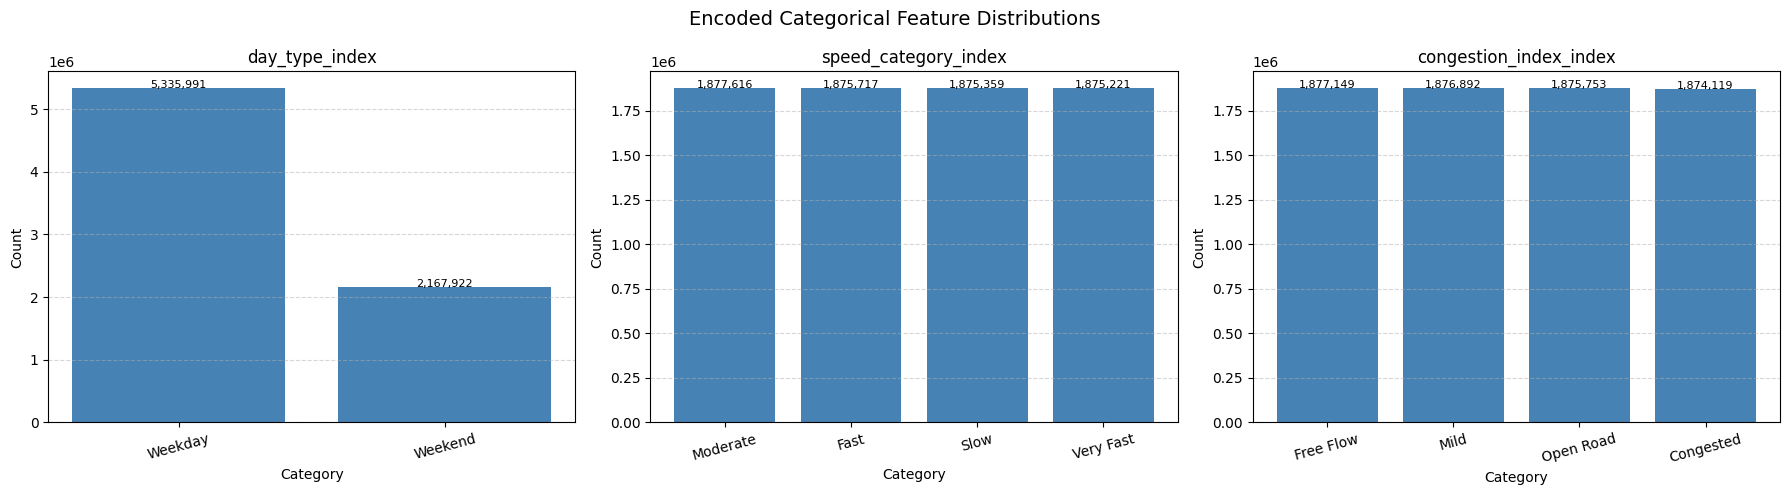

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Label mappings (from StringIndexer frequency encoding)
label_maps = {
    "day_type_index"         : {0: "Weekday", 1: "Weekend"},
    "speed_category_index"   : {0: "Moderate", 1: "Fast", 2: "Slow", 3: "Very Fast"},
    "congestion_index_index" : {0: "Free Flow", 1: "Mild", 2: "Open Road", 3: "Congested"}
}

for i, feat in enumerate(encoded_features):
    e_pdf = df.groupBy(feat).agg(count("*").alias("cnt")).orderBy(feat).toPandas()
    labels = [label_maps[feat].get(int(v), str(v)) for v in e_pdf[feat]]
    axes[i].bar(labels, e_pdf["cnt"], color="steelblue", edgecolor="none")
    axes[i].set_title(f"{feat}")
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=15)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)
    for j, (lbl, val) in enumerate(zip(labels, e_pdf["cnt"])):
        axes[i].text(j, val + 500, f"{val:,}", ha="center", fontsize=8)

plt.suptitle("Encoded Categorical Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

---

## 4. Feature vs Target Analysis

This section examines how each of the 19 features relates to the target variable `vehicle_count`. Pearson correlation quantifies linear relationships. Scatter plots visualise the relationship for continuous features. For encoded categorical features, group mean bar charts reveal whether different categories correspond to meaningfully different traffic volumes.

### 4.1 Pearson Correlation — All Features vs `vehicle_count`

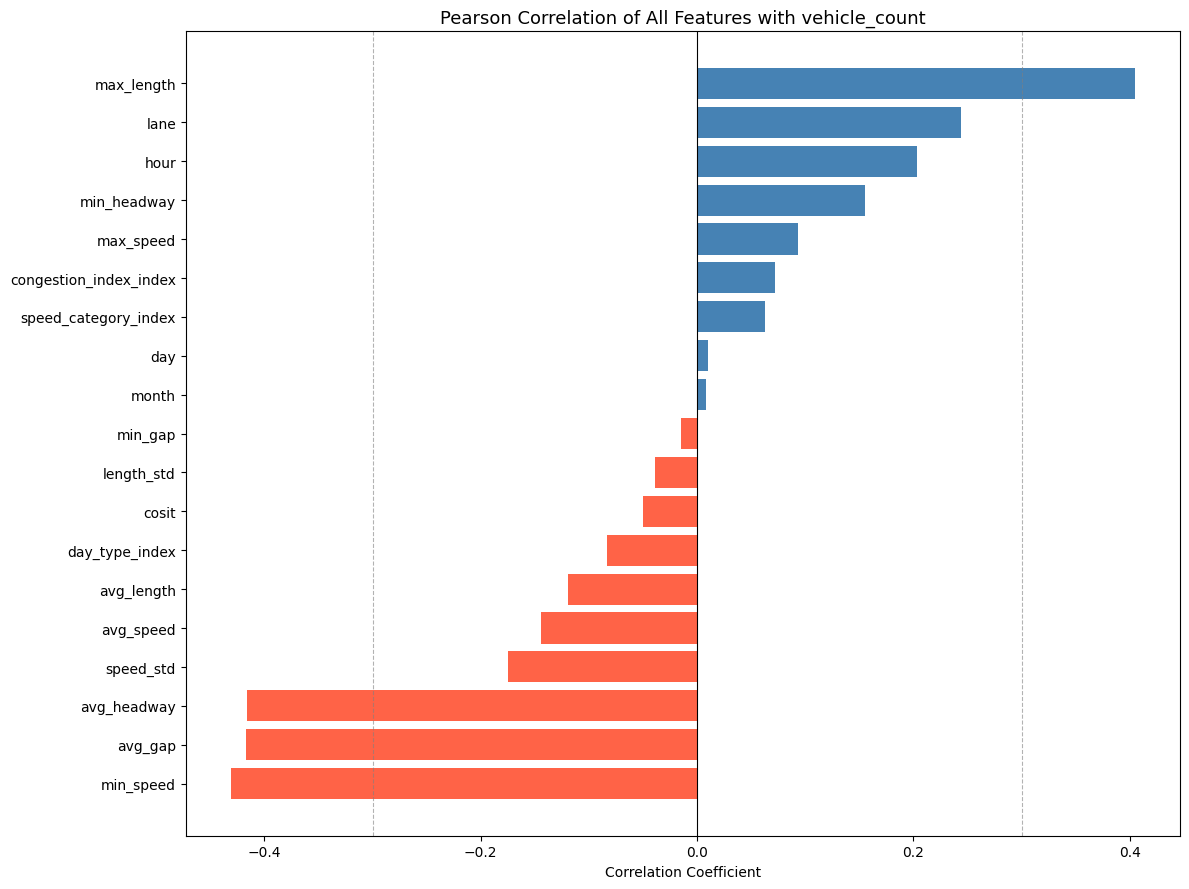

Rank  Feature                         Correlation
--------------------------------------------------
1     min_speed                           -0.4309
2     avg_gap                             -0.4168
3     avg_headway                         -0.4161
4     max_length                           0.4046
5     lane                                 0.2439
6     hour                                  0.203
7     speed_std                           -0.1746
8     min_headway                          0.1549
9     avg_speed                           -0.1446
10    avg_length                          -0.1189
11    max_speed                            0.0936
12    day_type_index                       -0.083
13    congestion_index_index                0.072
14    speed_category_index                 0.0625
15    cosit                               -0.0501
16    length_std                          -0.0389
17    min_gap                             -0.0145
18    day                                  0.0097

In [0]:
from pyspark.sql.functions import corr

corr_results = {}
for feat in all_features:
    val = df.select(corr(feat, target)).first()[0]
    corr_results[feat] = round(val, 4) if val is not None else 0.0

corr_sorted = dict(sorted(corr_results.items(), key=lambda x: x[1]))

colors = ["tomato" if v < 0 else "steelblue" for v in corr_sorted.values()]

plt.figure(figsize=(12, 9))
plt.barh(list(corr_sorted.keys()), list(corr_sorted.values()), color=colors, edgecolor="none")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.axvline(x=0.3,  color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
plt.axvline(x=-0.3, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
plt.title("Pearson Correlation of All Features with vehicle_count", fontsize=13)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

print(f"{'Rank':<5} {'Feature':<30} {'Correlation':>12}")
print("-" * 50)
for rank, (feat, val) in enumerate(sorted(corr_results.items(), key=lambda x: abs(x[1]), reverse=True), 1):
    print(f"{rank:<5} {feat:<30} {val:>12}")

### 4.2 Sensor Features vs `vehicle_count` — Scatter Plots

Scatter plots visualise the pairwise relationship between each sensor measurement feature and the target. A random sample of 10,000 rows is used for performance.

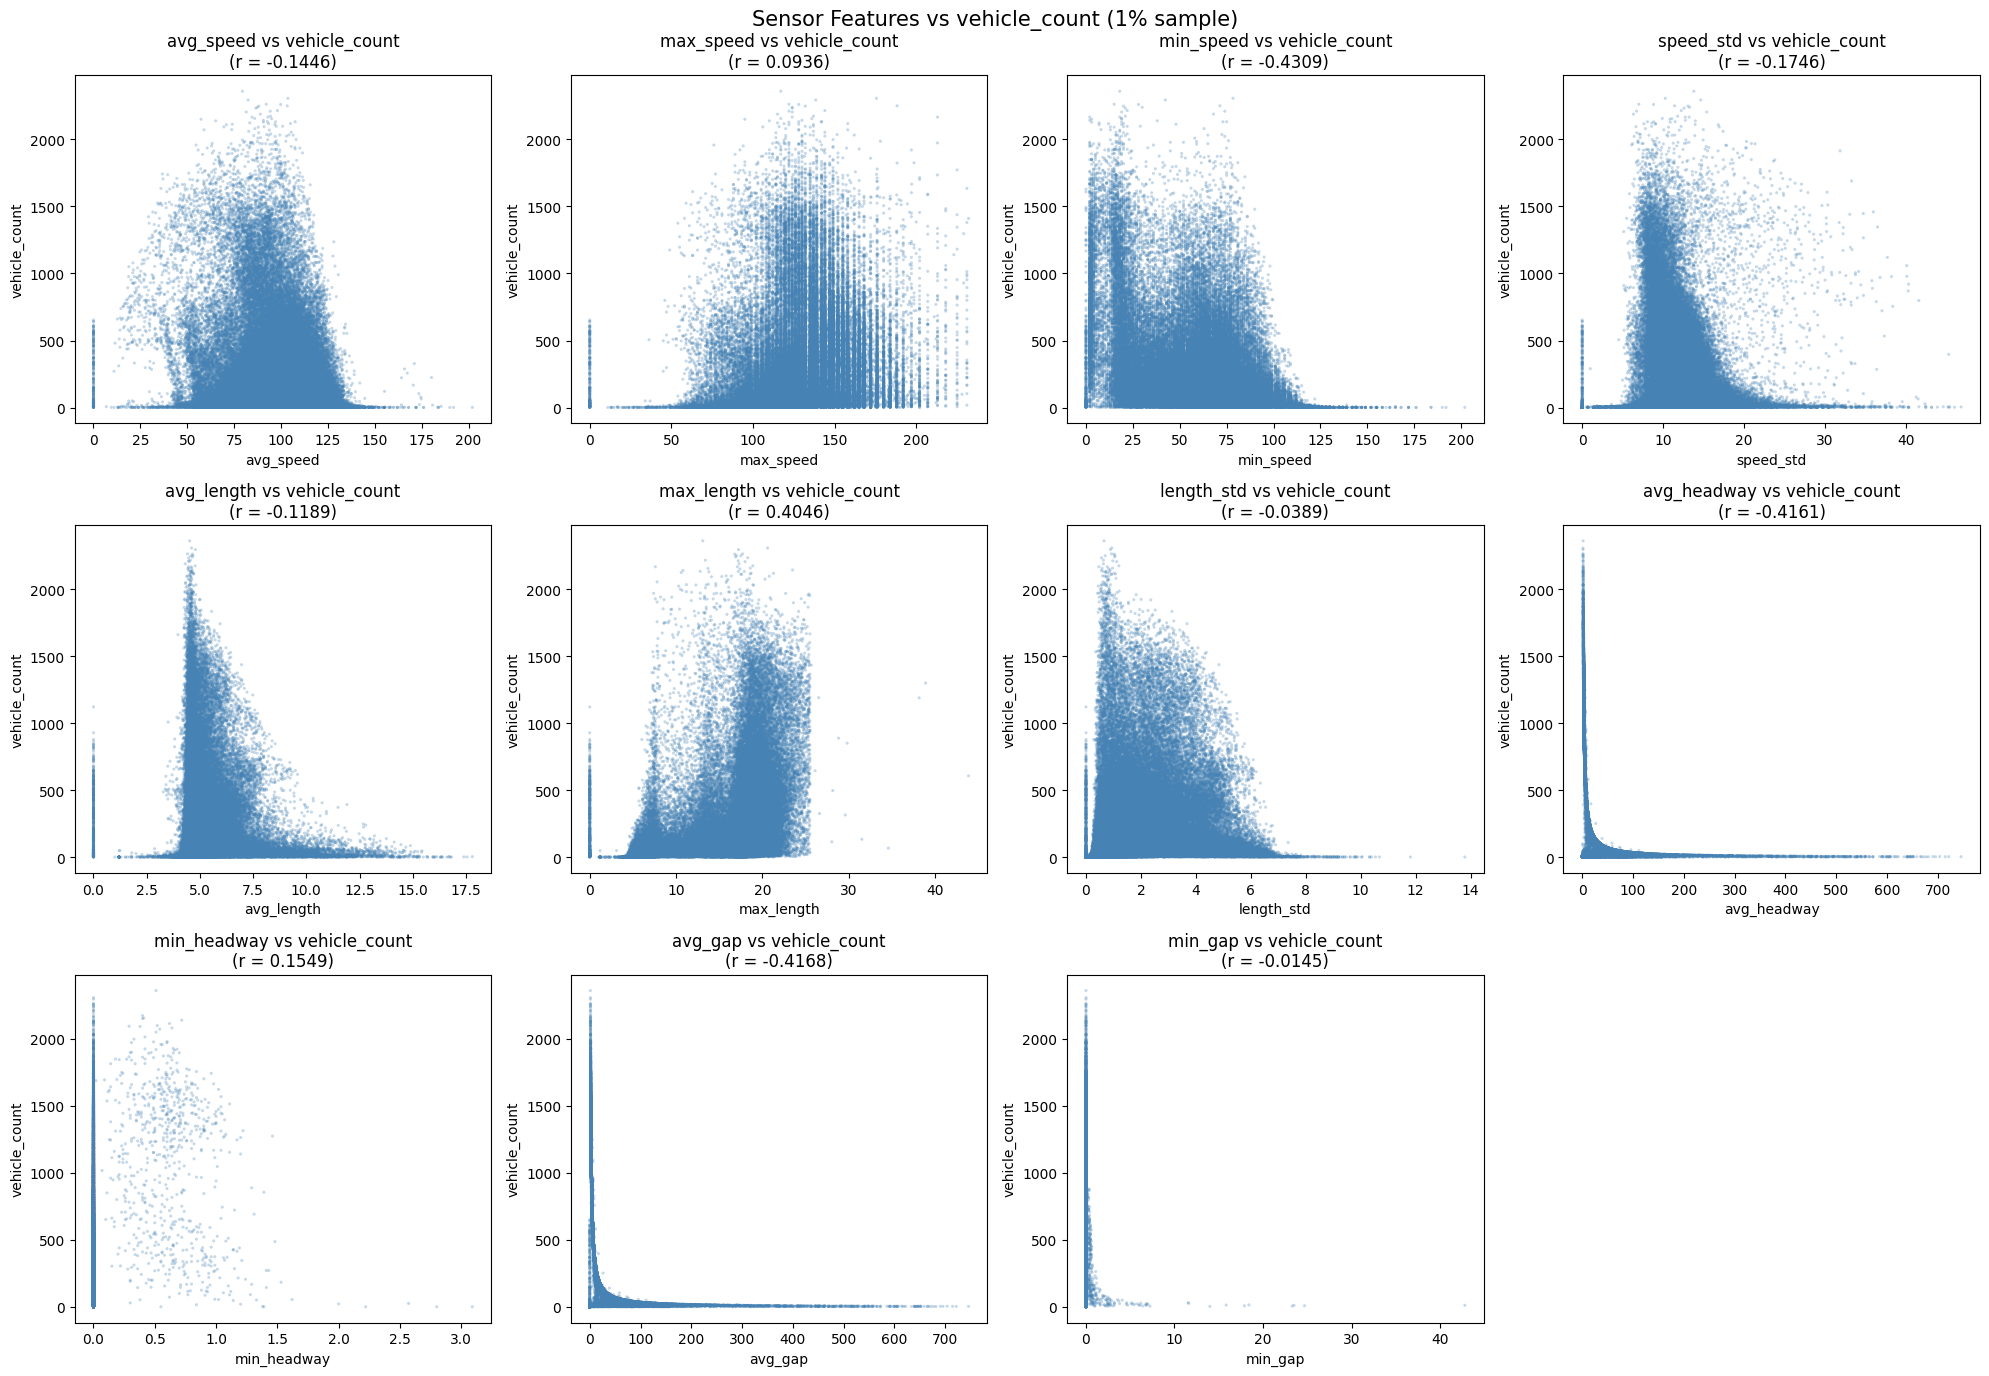

In [0]:
sample_pdf = df.select(sensor_features + [target]).sample(fraction=0.01, seed=42).toPandas()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    axes[i].scatter(sample_pdf[feat], sample_pdf[target],
                    alpha=0.3, s=5, color="steelblue", edgecolors="none")
    axes[i].set_title(f"{feat} vs vehicle_count\n(r = {corr_results[feat]})")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("vehicle_count")

for j in range(len(sensor_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sensor Features vs vehicle_count (1% sample)", fontsize=15)
plt.tight_layout()
plt.show()

### 4.3 Temporal Features vs `vehicle_count` — Group Mean Plots

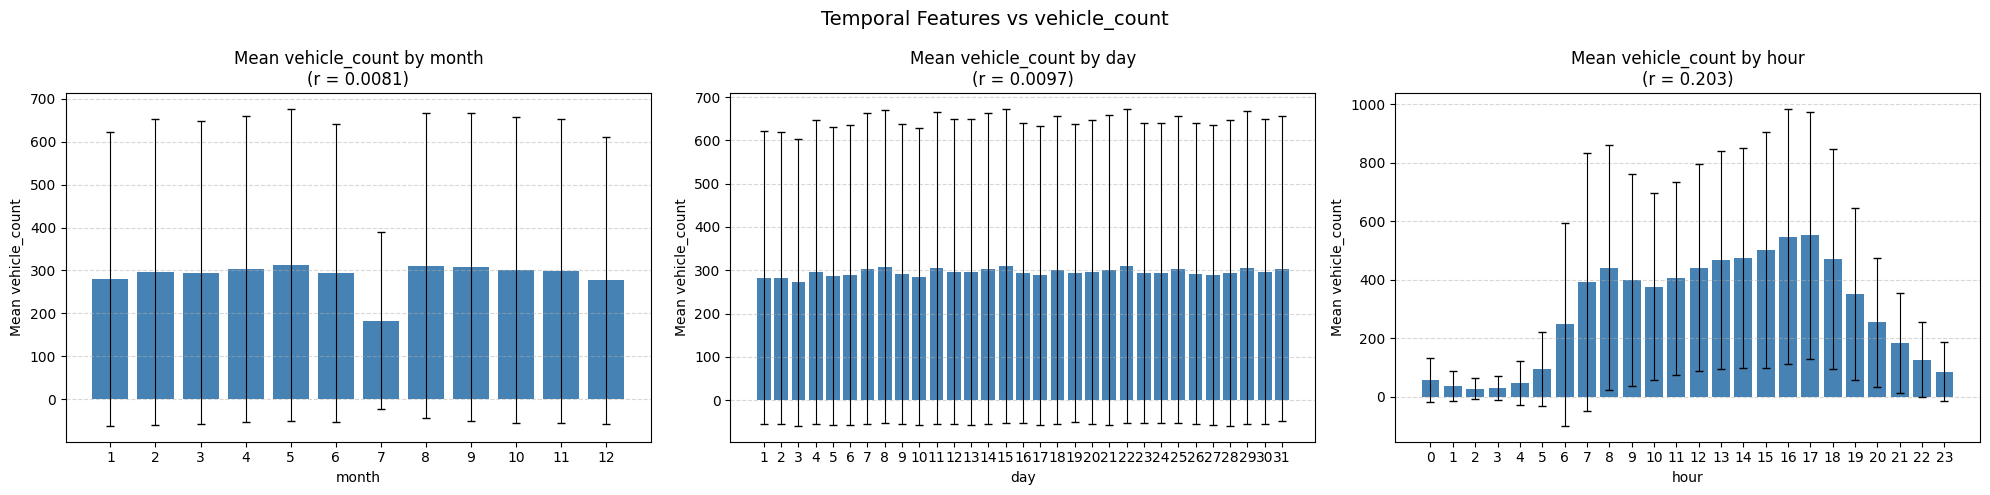

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, feat in enumerate(temporal_features):
    t_pdf = df.groupBy(feat).agg(
        avg("vehicle_count").alias("mean_vc"),
        stddev("vehicle_count").alias("std_vc")
    ).orderBy(feat).toPandas()

    axes[i].bar(t_pdf[feat].astype(str), t_pdf["mean_vc"],
                yerr=t_pdf["std_vc"], color="steelblue", edgecolor="none",
                capsize=3, error_kw={"elinewidth": 0.8})
    axes[i].set_title(f"Mean vehicle_count by {feat}\n(r = {corr_results[feat]})")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Mean vehicle_count")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Temporal Features vs vehicle_count", fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Encoded Categorical Features vs `vehicle_count` — Group Mean Plots

For each encoded categorical feature, mean `vehicle_count` is calculated per index value. A strong monotonic relationship between index and mean target value confirms predictive usefulness.

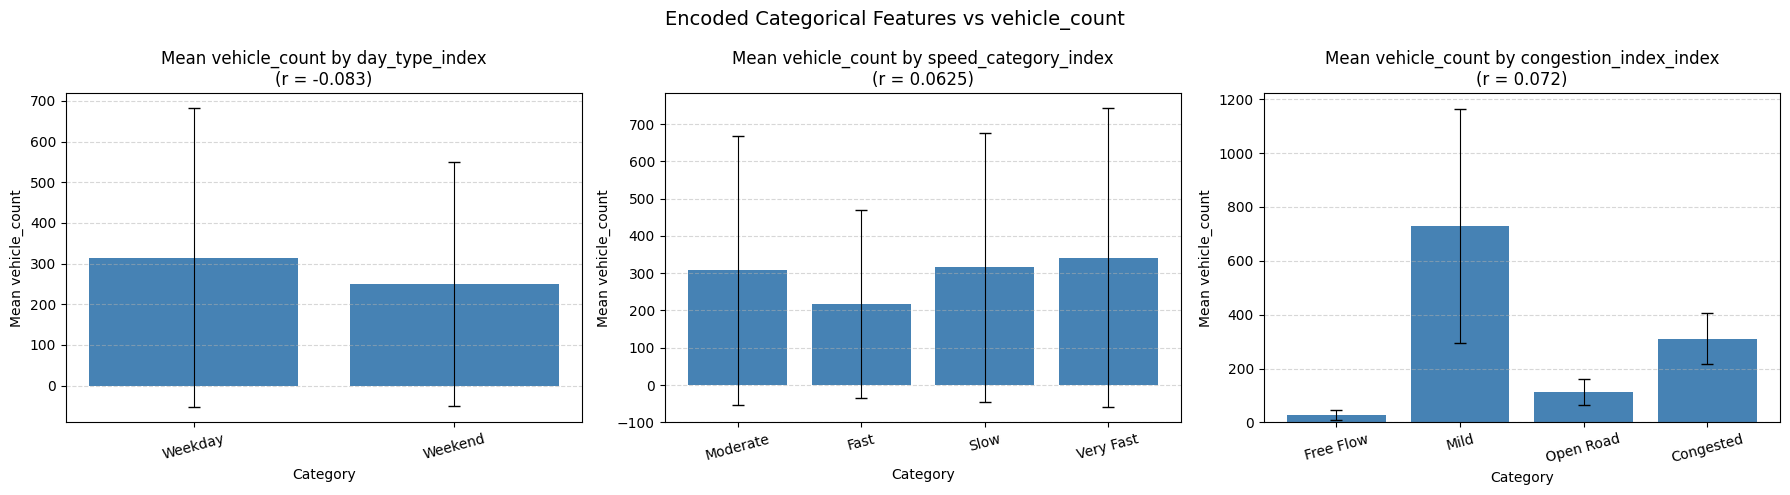

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(encoded_features):
    e_pdf = df.groupBy(feat).agg(
        avg("vehicle_count").alias("mean_vc"),
        stddev("vehicle_count").alias("std_vc")
    ).orderBy(feat).toPandas()

    labels = [label_maps[feat].get(int(v), str(v)) for v in e_pdf[feat]]
    axes[i].bar(labels, e_pdf["mean_vc"],
                yerr=e_pdf["std_vc"], color="steelblue", edgecolor="none",
                capsize=4, error_kw={"elinewidth": 0.8})
    axes[i].set_title(f"Mean vehicle_count by {feat}\n(r = {corr_results[feat]})")
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Mean vehicle_count")
    axes[i].tick_params(axis="x", rotation=15)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Encoded Categorical Features vs vehicle_count", fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 Location Features vs `vehicle_count`

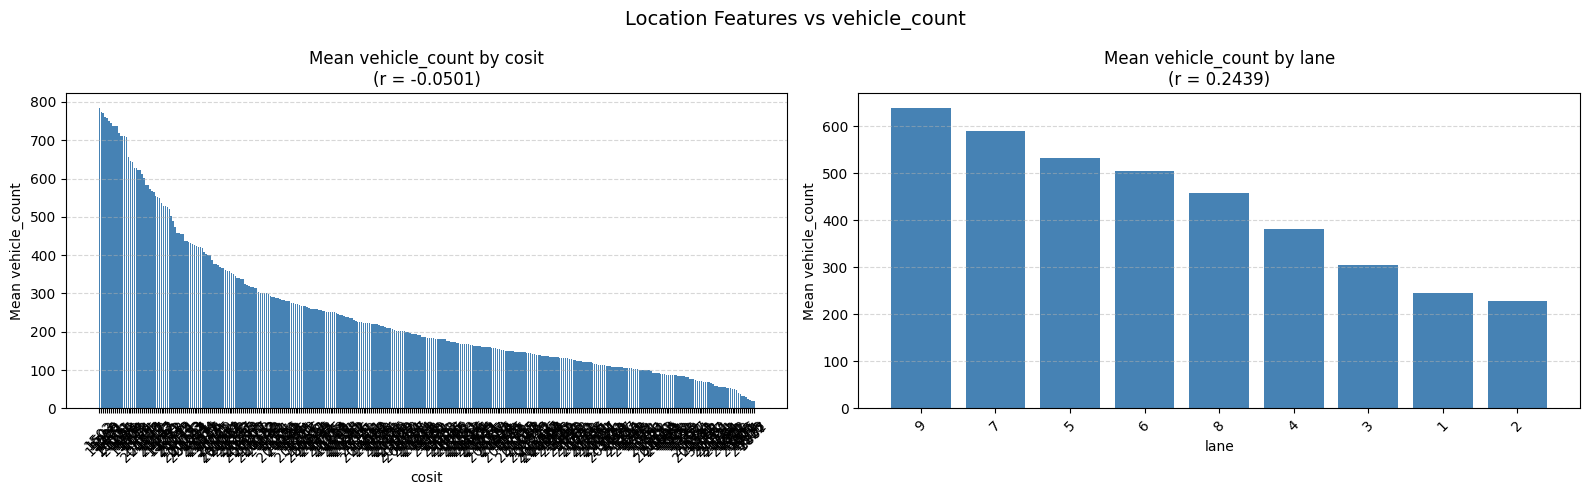

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, feat in enumerate(location_features):
    l_pdf = df.groupBy(feat).agg(
        avg("vehicle_count").alias("mean_vc")
    ).orderBy("mean_vc", ascending=False).toPandas()

    axes[i].bar(l_pdf[feat].astype(str), l_pdf["mean_vc"],
                color="steelblue", edgecolor="none")
    axes[i].set_title(f"Mean vehicle_count by {feat}\n(r = {corr_results[feat]})")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Mean vehicle_count")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Location Features vs vehicle_count", fontsize=14)
plt.tight_layout()
plt.show()

---

## 5. Feature vs Feature Analysis

This section examines relationships between the 19 input features themselves. The goal is to confirm that the multicollinearity removal performed in Notebook 3 has produced a clean, non-redundant feature set. We use a full correlation heatmap and targeted pairwise scatter plots for feature groups that might still share moderate correlations.

### 5.1 Full Correlation Heatmap — All 19 Features

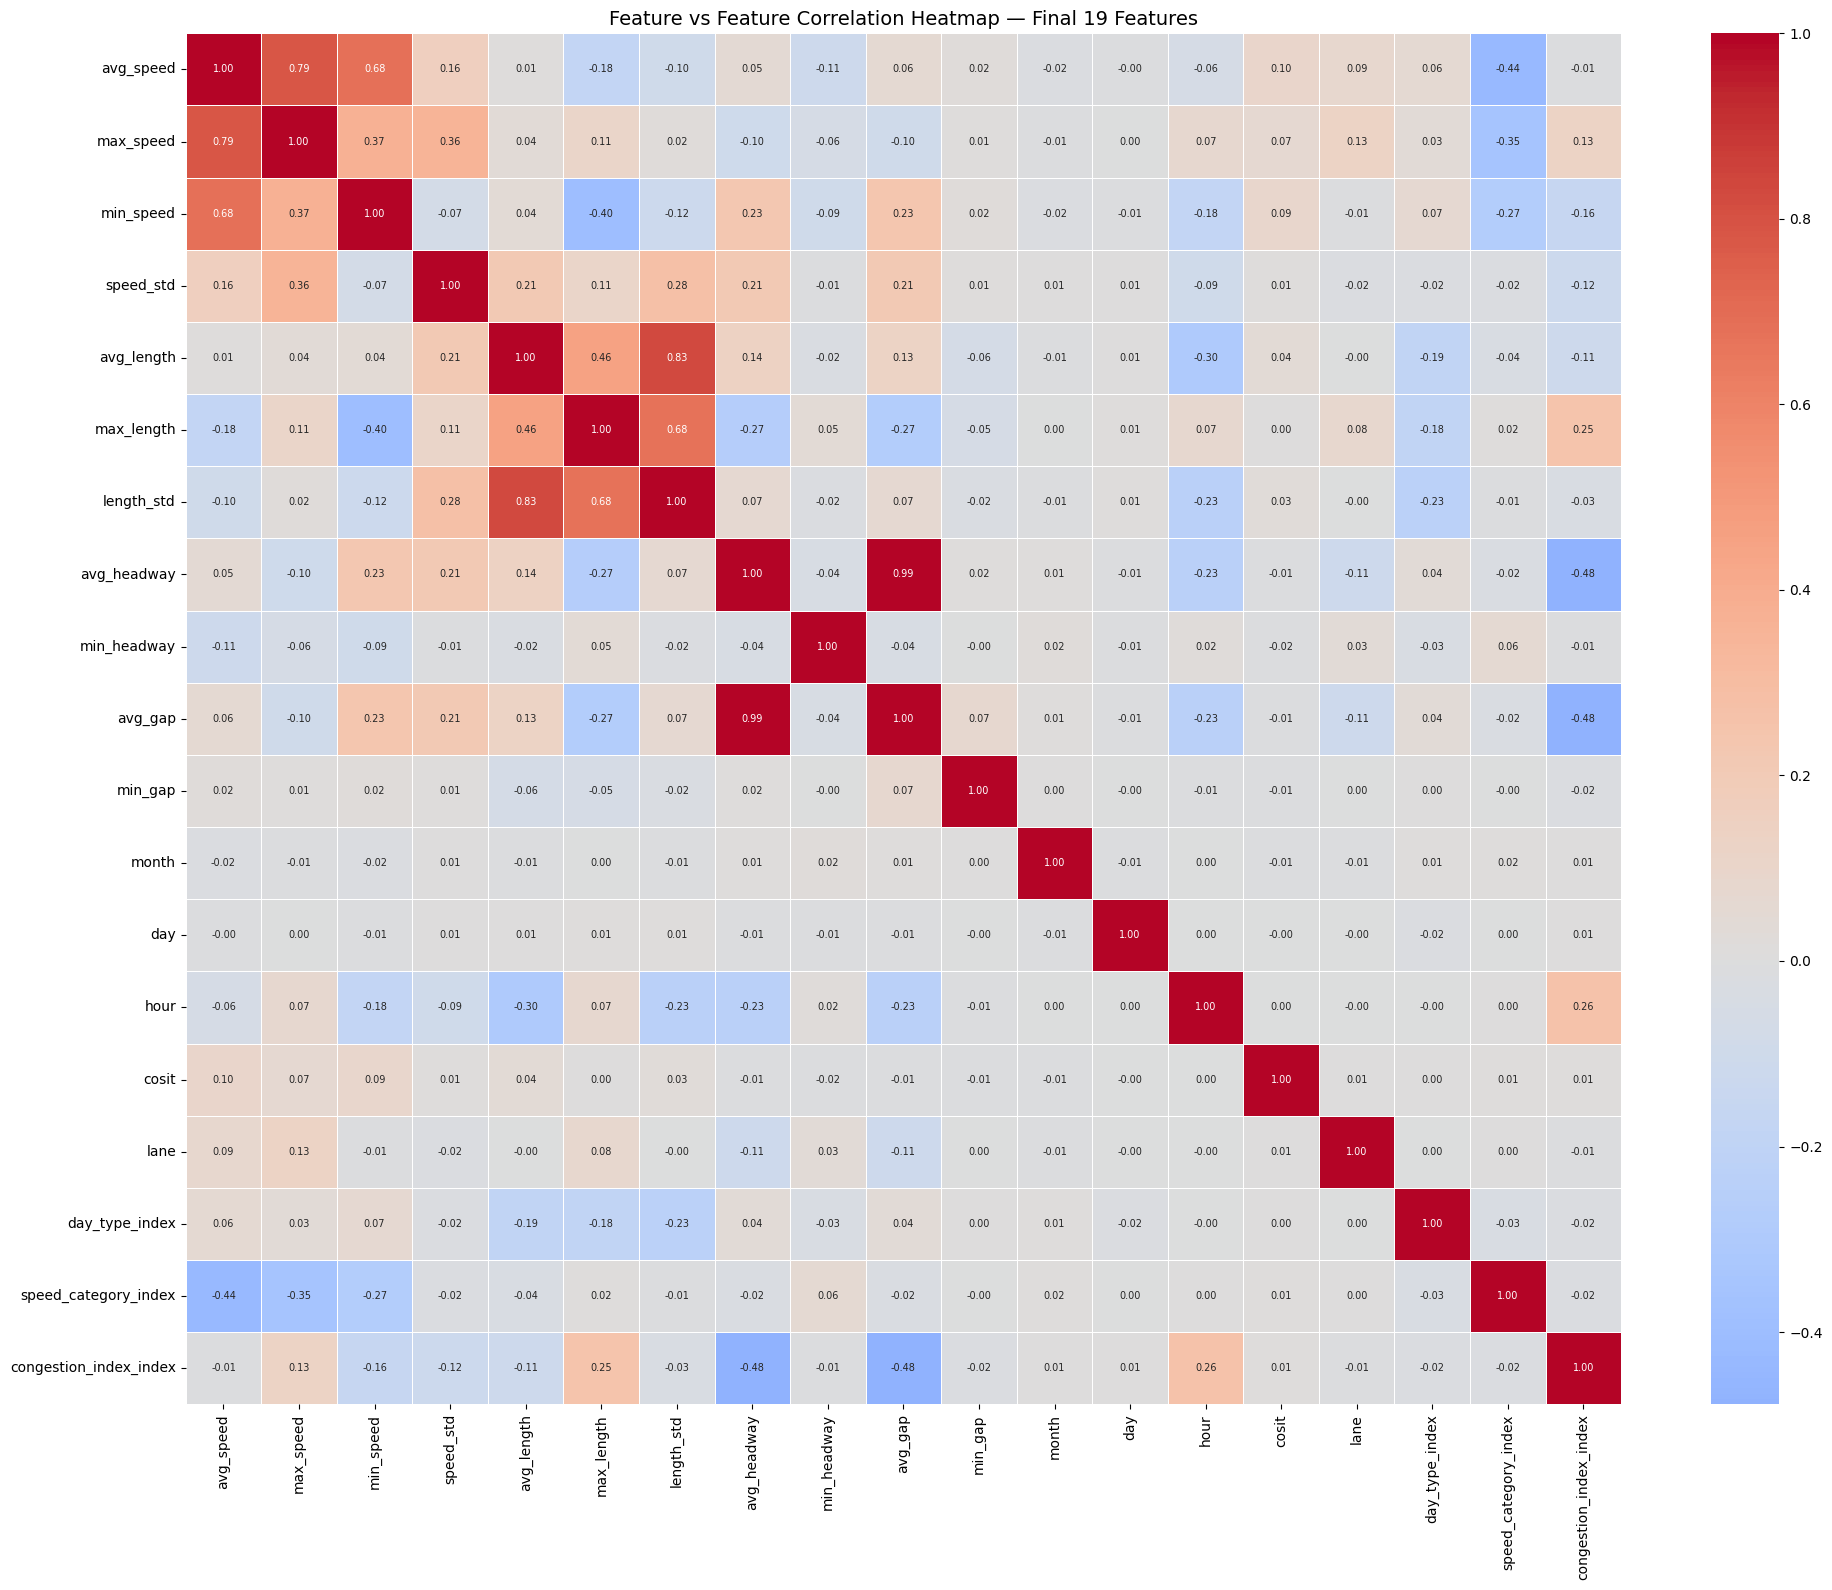

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample for performance, then compute correlation in pandas
sample_pdf = df.select(all_features).sample(fraction=0.1, seed=42).toPandas()

corr_pdf = sample_pdf.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_pdf,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    annot_kws={"size": 7}
)
plt.title("Feature vs Feature Correlation Heatmap — Final 19 Features", fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Highly Correlated Feature Pairs

We flag any remaining pairs with absolute correlation above 0.7 to verify that no strong multicollinearity persists in the final feature set.

In [0]:
threshold = 0.7
high_corr_pairs = []

for i in range(len(all_features)):
    for j in range(i + 1, len(all_features)):
        val = corr_pdf.iloc[i, j]
        if abs(val) > threshold:
            high_corr_pairs.append((all_features[i], all_features[j], round(val, 4)))

if high_corr_pairs:
    print(f"Feature pairs with |correlation| > {threshold}:")
    print("-" * 65)
    for f1, f2, v in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{f1:<28} vs {f2:<28} : {v}")
else:
    print(f"No feature pairs found with |correlation| > {threshold}.")

Feature pairs with |correlation| > 0.7:
-----------------------------------------------------------------
avg_headway                  vs avg_gap                      : 0.9949
avg_length                   vs length_std                   : 0.8279
avg_speed                    vs max_speed                    : 0.7859


### 5.3 Pairwise Scatter Plots — Speed Features

Speed-related features (`avg_speed`, `max_speed`, `min_speed`, `speed_std`) are grouped and visualised pairwise to inspect the nature of their relationships.

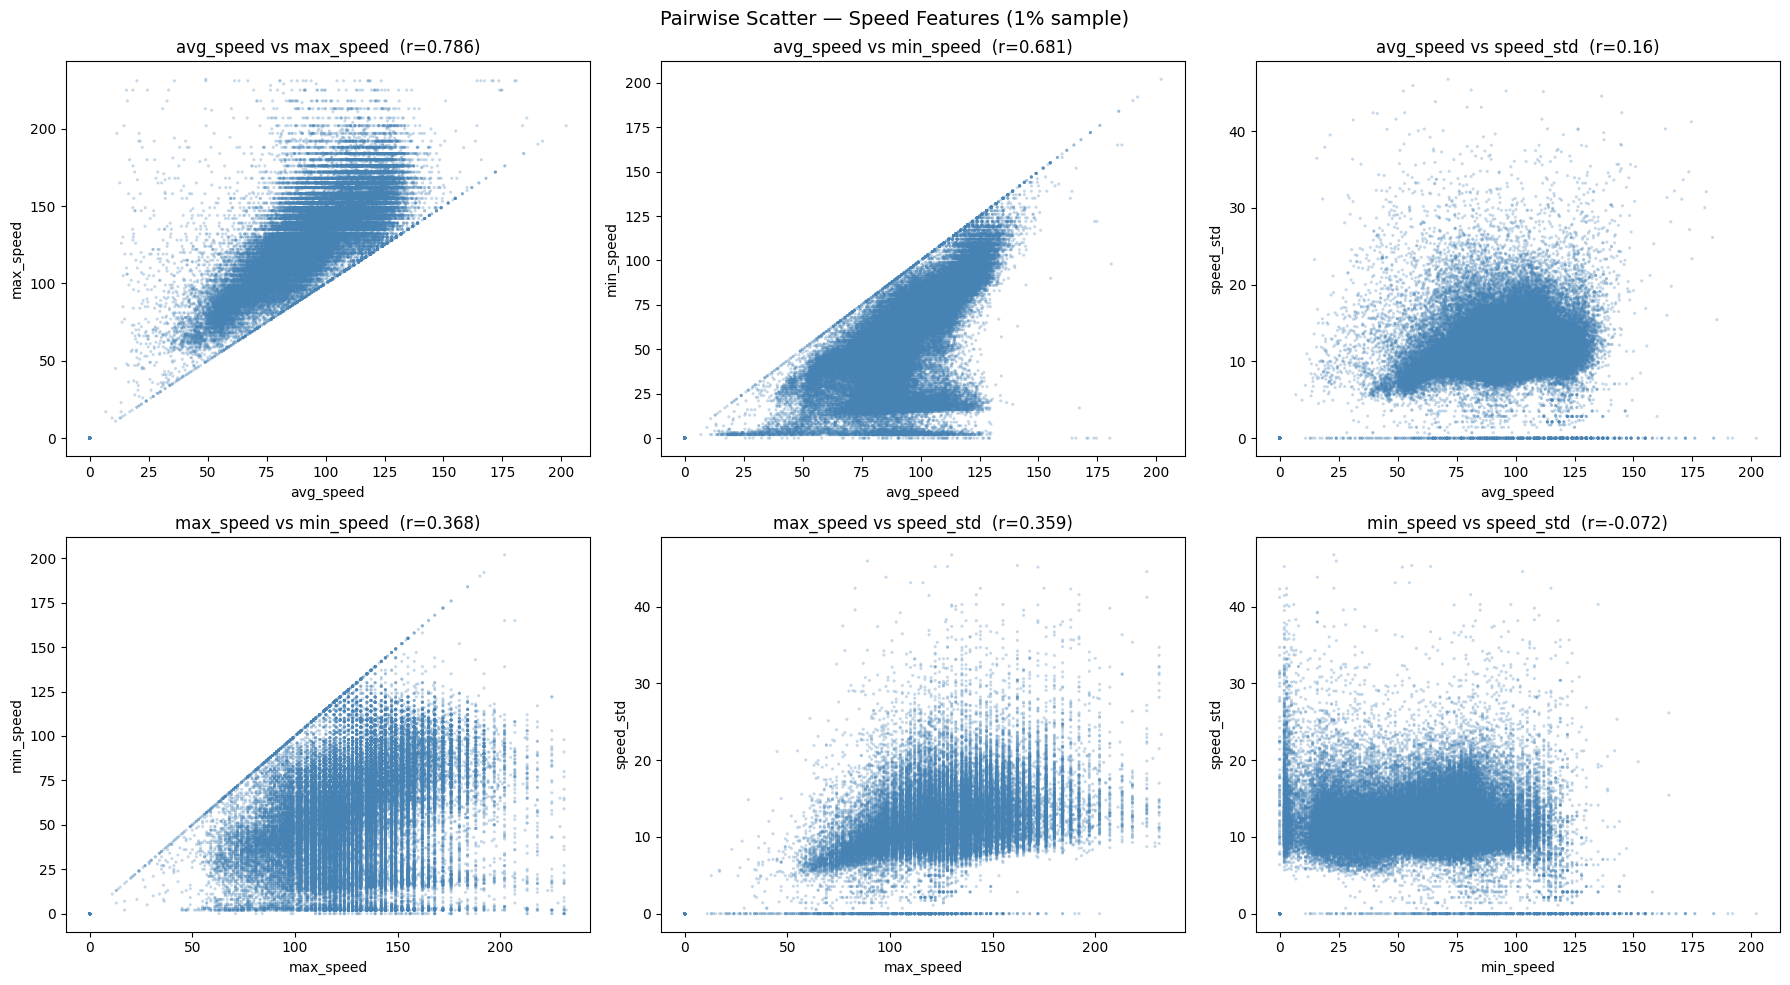

In [0]:
import itertools

speed_feats = ["avg_speed", "max_speed", "min_speed", "speed_std"]
speed_pdf   = df.select(speed_feats).sample(fraction=0.01, seed=42).toPandas()
pairs       = list(itertools.combinations(speed_feats, 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (f1, f2) in enumerate(pairs):
    axes[i].scatter(speed_pdf[f1], speed_pdf[f2],
                    alpha=0.3, s=5, color="steelblue", edgecolors="none")
    r = round(corr_pdf.loc[f1, f2], 3)
    axes[i].set_title(f"{f1} vs {f2}  (r={r})")
    axes[i].set_xlabel(f1)
    axes[i].set_ylabel(f2)

plt.suptitle("Pairwise Scatter — Speed Features (1% sample)", fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Pairwise Scatter Plots — Headway & Gap Features

`avg_headway`, `min_headway`, `avg_gap`, and `min_gap` are the retained representatives from the headway/gap cluster. We verify that the remaining pairs are not excessively correlated.

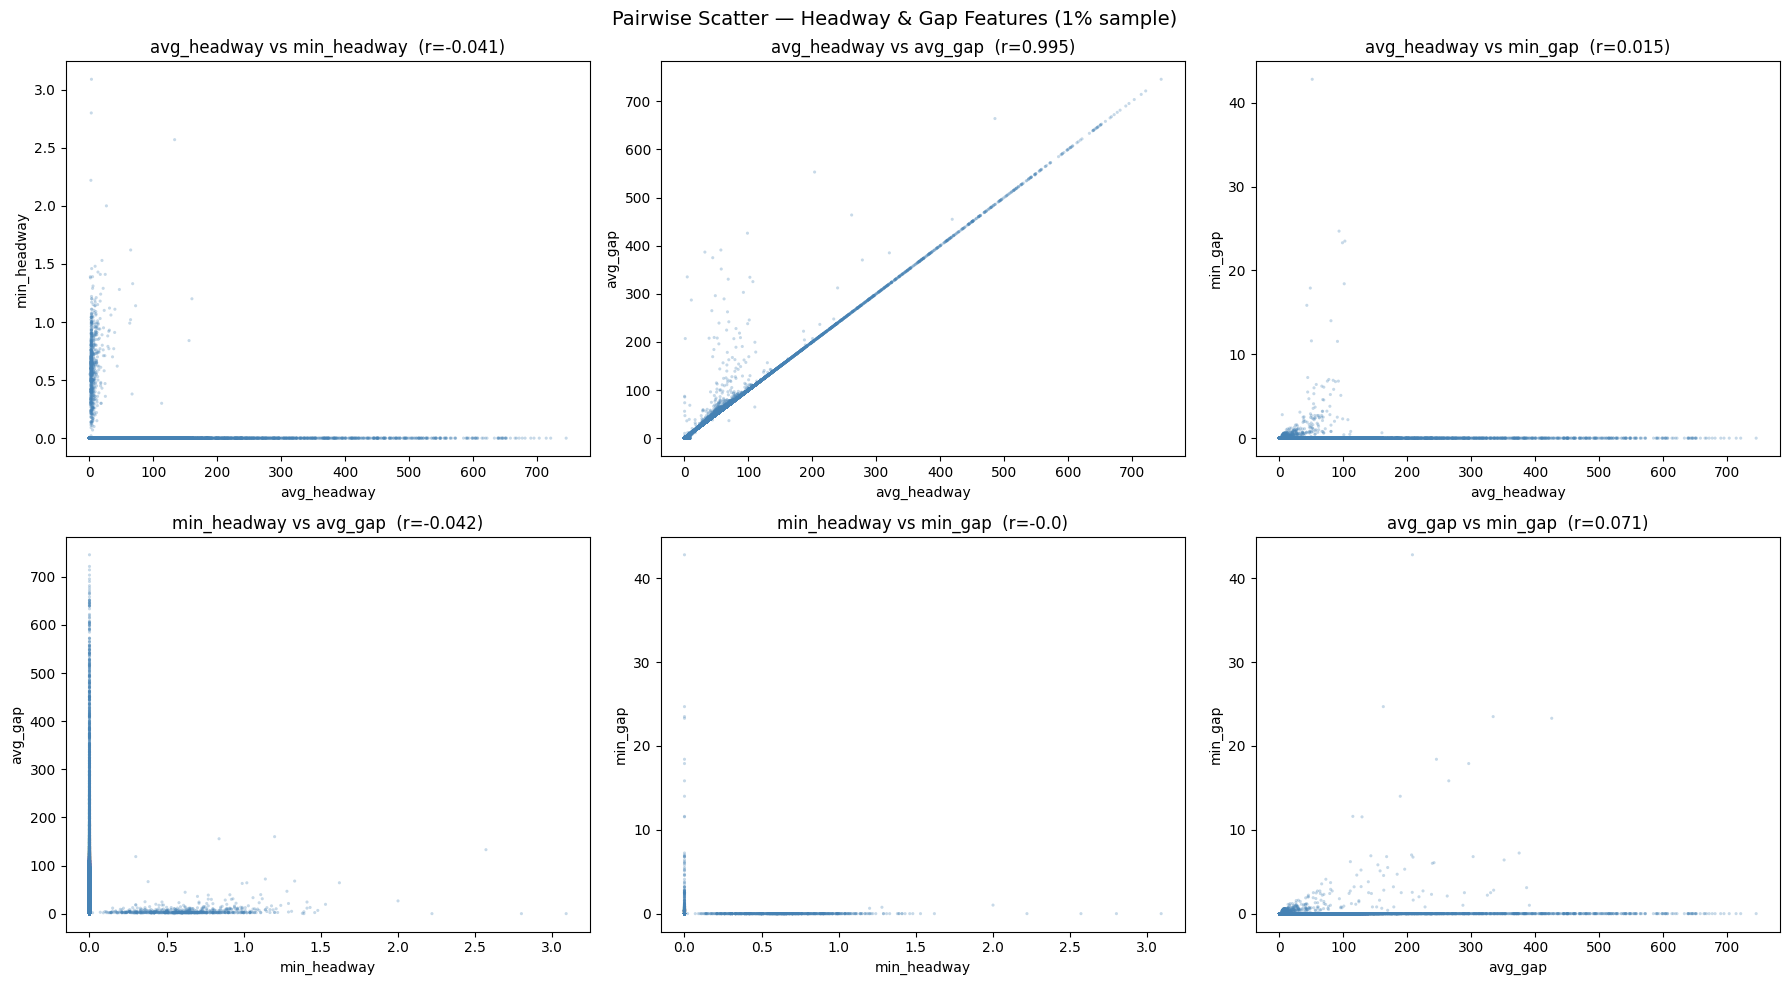

In [0]:
hw_gap_feats = ["avg_headway", "min_headway", "avg_gap", "min_gap"]
hw_pdf       = df.select(hw_gap_feats).sample(fraction=0.01, seed=42).toPandas()
pairs_hw     = list(itertools.combinations(hw_gap_feats, 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (f1, f2) in enumerate(pairs_hw):
    axes[i].scatter(hw_pdf[f1], hw_pdf[f2],
                    alpha=0.3, s=5, color="steelblue", edgecolors="none")
    r = round(corr_pdf.loc[f1, f2], 3)
    axes[i].set_title(f"{f1} vs {f2}  (r={r})")
    axes[i].set_xlabel(f1)
    axes[i].set_ylabel(f2)

plt.suptitle("Pairwise Scatter — Headway & Gap Features (1% sample)", fontsize=14)
plt.tight_layout()
plt.show()

---

## 6. EDA Summary

The following table summarises the key findings from this exploratory data analysis.

In [0]:
print("=" * 70)
print("EDA SUMMARY — Final 19 Feature Dataset")
print("=" * 70)

print("\n[1] DATASET")
print(f"    Rows    : {df.count():,}")
print(f"    Columns : {len(df.columns)} (19 features + 1 target)")
print( "    Nulls   : None (confirmed clean)")

print("\n[2] TARGET — vehicle_count")
print(f"    Right-skewed distribution with long upper tail")
print(f"    Strong hourly pattern — peak afternoon, near-zero at night")
print(f"    Variation across sensor sites (cosit) confirms location signal")

print("\n[3] STRONGEST PREDICTORS (by |correlation|)")
top5 = sorted(corr_results.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
for feat, val in top5:
    print(f"    {feat:<30} r = {val}")

print("\n[4] WEAKEST PREDICTORS (by |correlation|)")
bottom5 = sorted(corr_results.items(), key=lambda x: abs(x[1]))[:5]
for feat, val in bottom5:
    print(f"    {feat:<30} r = {val}")

print("\n[5] MULTICOLLINEARITY")
if high_corr_pairs:
    print(f"    {len(high_corr_pairs)} pair(s) above |0.7| — review before model training")
else:
    print("    No pairs above |0.7| — feature set is clean")

print("\n[6] NOTES")
print("    - Temporal features (hour, month, day) show strong cyclical patterns")
print("    - congestion_index_index is the most predictive encoded categorical feature")
print("    - Dataset is ready for baseline model training")
print("=" * 70)

EDA SUMMARY — Final 19 Feature Dataset

[1] DATASET
    Rows    : 7,503,913
    Columns : 20 (19 features + 1 target)
    Nulls   : None (confirmed clean)

[2] TARGET — vehicle_count
    Right-skewed distribution with long upper tail
    Strong hourly pattern — peak afternoon, near-zero at night
    Variation across sensor sites (cosit) confirms location signal

[3] STRONGEST PREDICTORS (by |correlation|)
    min_speed                      r = -0.4309
    avg_gap                        r = -0.4168
    avg_headway                    r = -0.4161
    max_length                     r = 0.4046
    lane                           r = 0.2439

[4] WEAKEST PREDICTORS (by |correlation|)
    month                          r = 0.0081
    day                            r = 0.0097
    min_gap                        r = -0.0145
    length_std                     r = -0.0389
    cosit                          r = -0.0501

[5] MULTICOLLINEARITY
    3 pair(s) above |0.7| — review before model training

[